In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df ['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Questions to Answer

1) What are the most demanded skills for the top 3 most popular data roles?
2) How are in-demand skills trending for Data Analysts?
3) How well do jobs and skills pay for Data Analysts?
4) What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

I'll be focusing on 'US' and 'Ind' Data Analyst roles, but you can adapt to any of the following:

---

first 

What are the most demanded skills for the top 3 most popular data
roles?

Methodology

1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Plot initial findings
4. Calculate skill percentage
5. Plot final findings

matplotlib adv section we did it here we will refine it

---

next

How are in-demand skills trending for Data Analysts?

Methology

1. Aggregate skill counts monthly
2. Plot the monthly skill counts
3. Re-analyze based on percentage of total jobs
4. Plot the monthly skill demand

this also we already did in adv chapter we will refine it

---

How well do jobs and skills pay for Data Analysts?

Methology

1. Evaluate median salary for all data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills
4. Visualize for highest demanded skills

in box plot we did it

---

and at last

What is the most optimal skill to learn for Data Analysts?

Methodology

1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

that scattered plot we will refine 

---

but first we need to get some insights..


for us location:-

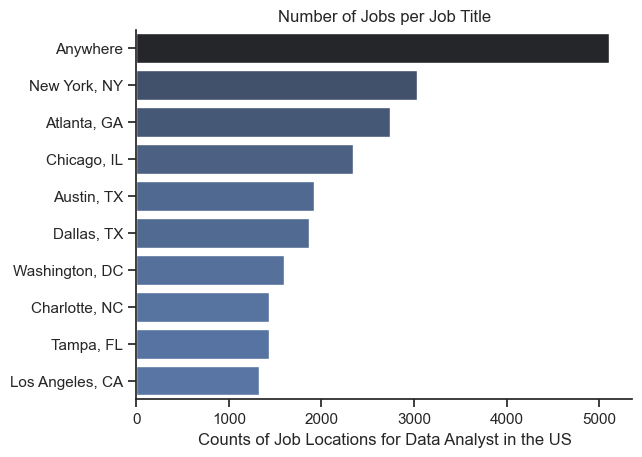

In [31]:
df_da_us = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst' )]

df_us_plot = df_da_us['job_location'].value_counts().head(10).to_frame()

import seaborn as sns
sns.set_theme(style ='ticks')

sns.barplot(data= df_us_plot , x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
# removes the border around the graph
plt.title('Number of Jobs per Job Title')
plt.xlabel('Counts of Job Locations for Data Analyst in the US')
plt.ylabel('') 
plt.show()

---

now explore boolean values of job_work_from_home , job_no_degree_mention ,  job_health_insurance already done this in pie charts so we will direclty take code from there

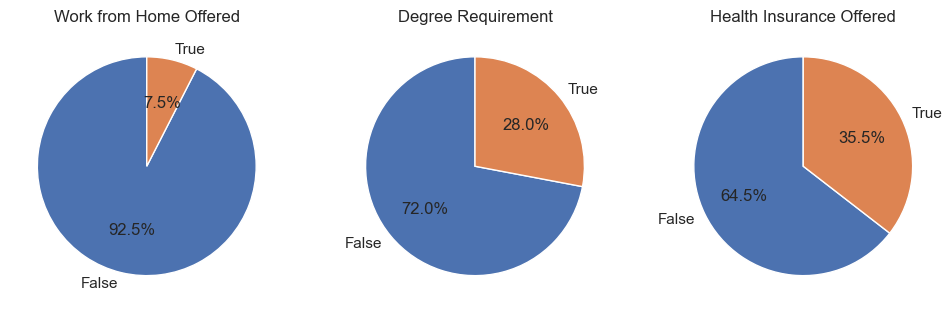

In [36]:
dict_column = {
'job_work_from_home': 'Work from Home Offered',
'job_no_degree_mention': 'Degree Requirement',
'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12,5))

for i, (column, title) in enumerate(dict_column.items()):
 ax[i].pie(df_da_us[column]. value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
 ax[i].set_title(title)

plt. show()

---

for company names

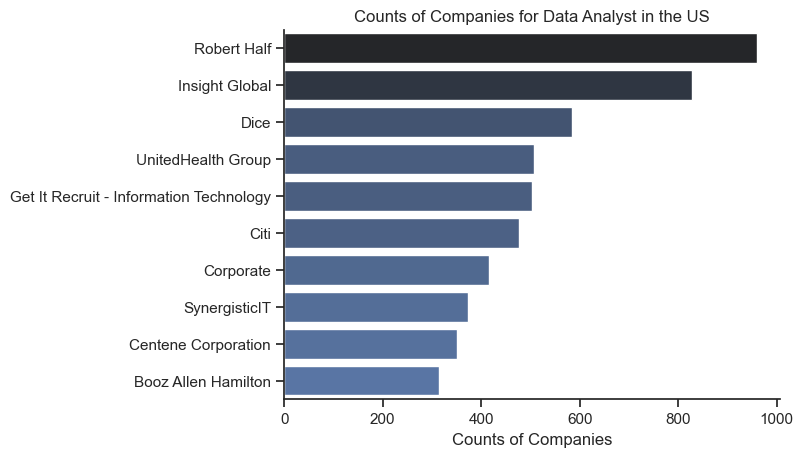

In [50]:

df_us_plot_company_names = df_da_us['company_name'].value_counts().head(10).to_frame()

import seaborn as sns
sns.set_theme(style ='ticks')
sns.barplot(data= df_us_plot_company_names , x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
# removes the border around the graph
plt.title('Counts of Companies for Data Analyst in the US')
plt.xlabel('Counts of Companies')
plt.ylabel('') 
plt.show()

---

---

for india:-

In [3]:
df_da_ind = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst' )]

In [6]:
df_ind_plot = df_da_ind['job_location'].value_counts().head(10).to_frame()

In [13]:
df_ind_plot

,count
job_location,
India,2056
"Hyderabad, Telangana, India",1289
Anywhere,1052
"Bengaluru, Karnataka, India",355
"Maharashtra, India",203
"Mumbai, Maharashtra, India",133
"Pune, Maharashtra, India",119
"Gurugram, Haryana, India",108
"Chennai, Tamil Nadu, India",106


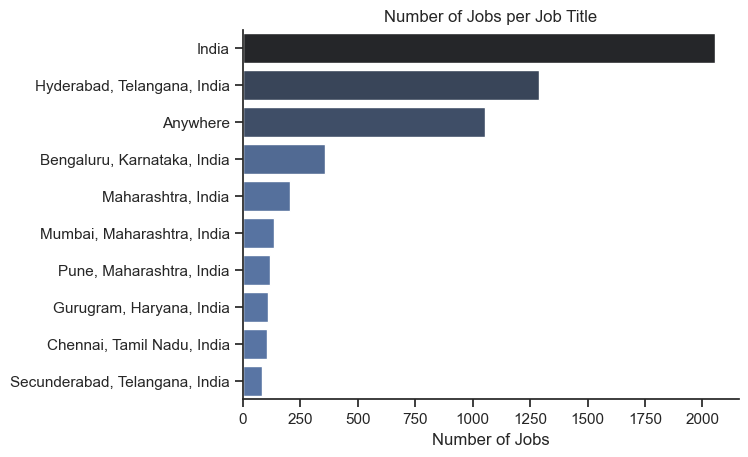

In [53]:
import seaborn as sns

import seaborn as sns
sns.set_theme(style ='ticks')

sns.barplot(data= df_ind_plot , x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('') 
plt.show()

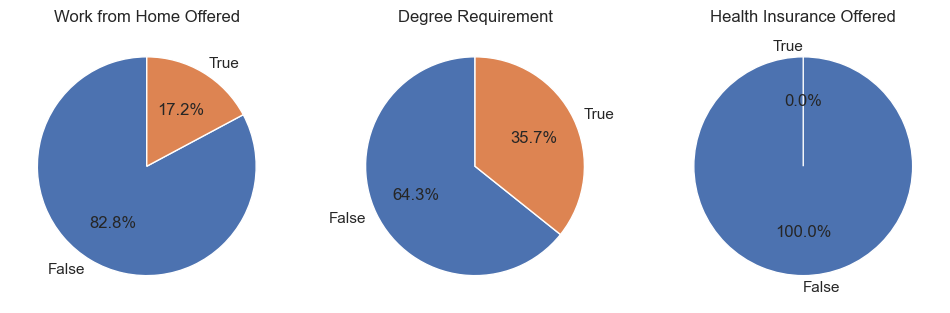

In [41]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    counts = df_da_ind[column].value_counts().reindex([False, True], fill_value=0)
    
    ax[i].pie(
        counts,
        labels=['False', 'True'],
        autopct='%1.1f%%',
        startangle=90
    )
    
    ax[i].set_title(title)

plt.show()

here some lables have labels = ['False', 'True']  ie  length = 2 so we re defined counts

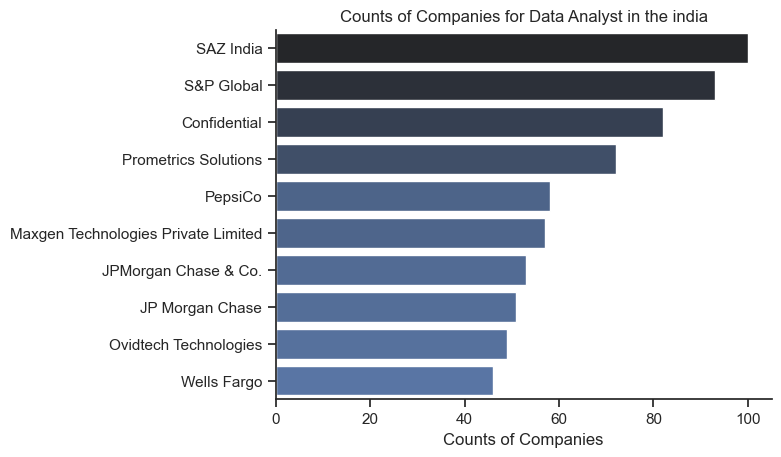

In [52]:

df_ind_plot_company_names = df_da_ind['company_name'].value_counts().head(10).to_frame()

import seaborn as sns
sns.set_theme(style ='ticks')
sns.barplot(data= df_ind_plot_company_names , x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
# removes the border around the graph
plt.title('Counts of Companies for Data Analyst in the india')
plt.xlabel('Counts of Companies')
plt.ylabel('') 
plt.show()

---